In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

import numpy as np
import random

from tqdm import tqdm
from IPython.display import clear_output

device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [28]:
ENV_NAME = 'cheetah' # cheetah | walker

In [29]:
NUM_TRAJECTORIES = 10000
TRAJECTORY_LEN = 1000

KEEP_ONLY_COORDS = False

In [30]:
import gym
import d4rl # Import required to register environments, you may need to also import the submodule

# Create the environment
from dm_control import suite

if ENV_NAME == 'cheetah':
    STATE_DIM = 18
    ACTION_DIM = 6
    AUX_DIM = 1
    env = suite.load(
        domain_name='cheetah',
        task_name='run',
        environment_kwargs=dict(flat_observation=True)
    )
    dataset = np.load('datasets/cheetah_rnd.npy', allow_pickle=True).item()
    aux = np.load('datasets/aux_cheetah.npy')
    dataset['observations'] = np.concatenate((dataset['observations'], aux.reshape(10000, 1000, 1)), axis=-1)
    
else:
    STATE_DIM = 27
    ACTION_DIM = 6
    AUX_DIM = 3
    env = suite.load(
        domain_name='walker',
        task_name='run',
        environment_kwargs=dict(flat_observation=True)
    )
    dataset = np.load('datasets/walker_rnd.npy', allow_pickle=True).item()
    aux = np.load('datasets/aux_walker.npy')
    dataset['observations'] = np.concatenate((dataset['observations'], aux.reshape(10000, 1000, 3)), axis=-1)

In [31]:
dataset_trajectories = torch.tensor(dataset['observations']).float()
dataset_trajectories = dataset_trajectories
# dataset_trajectories = torch.concatenate((dataset_trajectories[..., [0, 1]], dataset_trajectories[..., [15, 16]]), dim=-1)

dataset_actions = torch.tensor(dataset['actions']).float()
dataset_terminals = torch.tensor(dataset['terminals']).float()
dataset_timeouts = torch.zeros(NUM_TRAJECTORIES, TRAJECTORY_LEN).bool()
dataset_timeouts[:, -1] = True

dataset_goals = torch.tensor(dataset['infos/goal']).float()



dataset_trajectories = dataset_trajectories.reshape(-1, TRAJECTORY_LEN, STATE_DIM)
dataset_actions = dataset_actions.reshape(-1, TRAJECTORY_LEN, ACTION_DIM)
dataset_terminals = dataset_terminals
dataset_timeouts = dataset_timeouts.reshape(-1, TRAJECTORY_LEN)


num_trajectories, len_trajectory, obs_dim = dataset_trajectories.shape

In [32]:
dataset_mean = dataset_trajectories.mean([0, 1])
dataset_std = dataset_trajectories.std([0, 1])


def normalize_dataset_coords(dataset_):
    return dataset_

def denormalize_dataset_coords(dataset_):
    return dataset_

dataset_trajectories = normalize_dataset_coords(dataset_trajectories)
dataset_trajectories_cuda = dataset_trajectories.to(device)


In [33]:
# x = torch.tensor(dataset['physics'][:, -1, 0])


# num_bins = 200

# # Compute bin edges
# bin_edges = torch.linspace(x.min(), x.max(), num_bins + 1)

# # Assign each element to a bin
# bin_indices = torch.bucketize(x, bin_edges, right=False) - 1  # -1 to make bins 0-indexed

# # For each bin, pick one index (here, the first occurrence)
# selected_indices = []
# for b in range(num_bins):
#     inds_in_bin = torch.nonzero(bin_indices == b, as_tuple=False).squeeze()
#     if inds_in_bin.numel() > 0:
#         selected_indices.append(inds_in_bin[0].item() if len(inds_in_bin.shape) != 0 else inds_in_bin.item())  # pick the first one

# selected_indices = torch.tensor(selected_indices)


# plt.figure(figsize=(20, 5))
# plt.scatter(
#     dataset['physics'][selected_indices, :, 0],
#     torch.arange(1000).unsqueeze(0).repeat(selected_indices.shape[0], 1),
#     c='red', s=1, alpha=0.1
# )

# plt.xlabel('x-coordinate')
# plt.ylabel('timestep')

In [34]:
import torch
import torch.nn as nn
import math

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        # Create a long enough PEs tensor
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        # (1, max_len, d_model) so it can be broadcast over batch
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        # x: (batch_size, seq_len, d_model)
        x = x + self.pe[:, :x.size(1), :]  # match seq_len
        return self.dropout(x)


In [35]:
class FRENetwork(nn.Module):
    def __init__(self, state_dim, action_dim, num_heads=2, num_layers=2, d_model=128):
        super().__init__()
        
        self.state_dim = state_dim
        self.action_dim = action_dim
        self.d_model = d_model
        self.num_discrete_embeddings = 32
        
        self.encoder_transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                self.d_model, 
                num_heads, 
                dim_feedforward=4*self.d_model, 
                batch_first=True
            ),
            num_layers=num_layers
        )
        self.encoder_mean = nn.Linear(self.d_model, self.d_model)
        self.encoder_log_std = nn.Linear(self.d_model, self.d_model)

        self.state_embed = nn.Linear(self.state_dim, self.d_model // 2)
        self.action_embed = nn.Linear(self.action_dim, self.d_model // 2)

        self.action_predict = nn.Sequential(
            nn.Linear(self.state_dim + self.d_model, 512),
            nn.LayerNorm(512),
            nn.Mish(),
            nn.Linear(512, 512),
            nn.LayerNorm(512),
            nn.Mish(),
            nn.Linear(512, 512),
            nn.LayerNorm(512),
            nn.Mish(),
            nn.Linear(512, action_dim),
            nn.Tanh()
        )
        
        self.positional_encoding = PositionalEncoding(d_model=d_model, dropout=0.1, max_len=200)



    def get_transformer_encoding(self, states, actions, pad_mask):  
        
        batch_size, num_anchors = states.shape[0], states.shape[1]
        
        if pad_mask is None:
            pad_mask = torch.zeros((batch_size, num_anchors), dtype=torch.bool, device=states.device)
        # pad_mask.shape = [batch, anchors]
                
        state_emb = self.state_embed(states)
        action_emb = self.action_embed(actions)
        
        state_action_emb = torch.concat([state_emb, action_emb], dim=-1)
        
        x = self.positional_encoding(state_action_emb)
        w_pre = self.encoder_transformer(x, src_key_padding_mask=pad_mask) # [batch, anchors, emb_dim]
        
        
        valid_tokens = (~pad_mask).float()  # (B, T), converts True -> 0, False -> 1
        valid_tokens = valid_tokens.unsqueeze(-1)  # (B, T, 1)
        sum_embeddings = (w_pre * valid_tokens).sum(dim=1)  # Sum over sequence dimension
        w_pair_mean = sum_embeddings / valid_tokens.sum(dim=1)
        
        # w_pair_mean = w_pre.mean(axis=1)
        # print(w_pair_mean.shape)
        w_mean = self.encoder_mean(w_pair_mean)
        w_log_std = self.encoder_log_std(w_pair_mean)

        return w_mean, w_log_std # (batch_size, emb_dim)
    
    
    def get_action_pred(self, w, states): # Reward Pairs: [batch, seq, obs_dim]
        z_expand = w.unsqueeze(1) # [batch, 1, emb_dim]
        z_expand = z_expand.repeat(1, states.shape[1], 1)        
        
        w_and_obs = torch.concatenate([z_expand, states], axis=-1)
        
        reward_pred = self.action_predict(w_and_obs)
        
        return reward_pred # [batch, reward_pairs]
        

# FRE:

In [36]:
class MLPRewards:
    def __init__(self, N, obs_len):

        self.N = N
        
        self.param_w1 = torch.normal(0, 1, size=(self.N, obs_len, 32), device=device) * np.sqrt(1/32)
        self.param_b1 = torch.normal(0, 1, size=(self.N, 1, 32), device=device) * np.sqrt(16)
        self.param_w2 = torch.normal(0, 1, size=(self.N, 32, 1), device=device) * np.sqrt(1/16)
        
        if obs_len == 18:
            self.param_w1[:, -1:] = 0
        elif obs_len == 27:
            self.param_w1[:, -3:] = 0
            
    
    def sample(self, N):
        return torch.randint(0, self.N, (N,))

    def __call__(self, obs, param_id=None):
        """
        obs.shape = (batch_size, num_samples, obs_dim)
        param_id.shape = (batch_size, 1)
        """
        
        batch_size, num_samples, obs_dim = obs.shape
        batch_size_, _ = param_id.shape
        assert (batch_size == batch_size_)
        
        device = obs.device
        
        if param_id is None:
            param_id = torch.randint(0, self.N, size=(obs.shape[0], 1))
        
        param_id_expanded = param_id.repeat(1, obs.shape[1])
        param1_w = self.param_w1[param_id_expanded]
        param1_b = self.param_b1[param_id_expanded]
        param2_w = self.param_w2[param_id_expanded]

        # obs[..., 2:] = 0.0

        x = torch.unsqueeze(obs, -2) # [batch, (pairs), 1, features_in]
        x = torch.matmul(x, param1_w) # [batch, (pairs), 1, features_out]
        x = x + param1_b
        x = torch.tanh(x)
        r = torch.matmul(x, param2_w) # [batch, (pairs), 1, 1]
        r = r.squeeze(-1).squeeze(-1) # [batch, (pairs)]
        r = torch.clip(r, -1, 1)

        return r, param_id
    
# mlp_rewards = MLPRewards(N=10000, obs_len=29)

In [37]:
class LinearRewards:
    def __init__(self, N, obs_len):

        self.N = N
        
        self.param_w1 = torch.rand(size=(self.N, obs_len, 1), device=device) * 2 - 1
        self.random_mask = torch.rand(size=(self.N, obs_len), device=device) < 0.9
        # self.random_mask[..., :2] = True
        
        random_mask_positive = np.random.randint(2, obs_len, size=(N,))
        self.random_mask[np.arange(N), random_mask_positive] = False # Force at least one positive weight.
        
        if obs_len == 18:
            self.param_w1[:, -1:] = 0
        elif obs_len == 27:
            self.param_w1[:, -3:] = 0
            
            
            
        

    def sample(self, N):
        return torch.randint(0, self.N, (N,))

    def __call__(self, obs, param_id=None):
        """
        obs.shape = (batch_size, num_samples, obs_dim)
        param_id.shape = (batch_size, 1)
        """
        
        batch_size, num_samples, obs_dim = obs.shape
        batch_size_, _ = param_id.shape
        assert (batch_size == batch_size_)
        
        device = obs.device
        
        if param_id is None:
            param_id = torch.randint(0, self.N, size=(obs.shape[0], 1))
        
        param_id_expanded = param_id.repeat(1, obs.shape[1])
        param1_w = self.param_w1[param_id_expanded]
        mask = self.random_mask[param_id_expanded]
        obs = (~mask) * obs
        
        x = torch.unsqueeze(obs, -2) # [batch, (pairs), 1, features_in]
        r = torch.matmul(x, param1_w) # [batch, (pairs), 1, features_out]
        r = r.squeeze(-1).squeeze(-1) # [batch, (pairs)]
        r = torch.clip(r, -1, 1)

        return r, param_id

In [38]:
class GoalRewards:
    def __init__(self):
        pass
    
    def sample_goals(self, N):
        goals = dataset_trajectories[
            torch.randint(0, num_trajectories, (N,)),
            torch.randint(0, len_trajectory, (N,)),
        ]
        return goals
    
    # def get_states(self, num_states, goals):
    #     cond = (dataset_trajectories[..., :2] - goal[..., :2]).norm(dim=-1) < 0.5
    #     dataset_trajectories_cuda[cond][torch.randint(0, cond.sum(), (1,))]
    
    def __call__(self, obs, goals=None):
        """
        obs.shape = (batch_size, num_samples, obs_dim)
        param.shape = (batch_size, obs_dim)
        """
        
        if obs.shape[-1] == 18:
            std = torch.tensor([[0.4407440506721877, 10.070289916801876, 0.5172332956856273, 0.5601041145815341, 0.518947027289748, 0.3204431592542281, 0.5501848643154092, 0.3856393812067661, 1.9882502334402663, 1.6377168569884073, 4.308505013609855, 12.144181770553105, 13.537567521831702, 16.88983033626308, 7.715009572436841, 14.345667964212357, 10.6904255152284, 100]])
        elif obs.shape[-1] == 27:
            std = torch.tensor([[0.7212967364054736, 0.6775020895964047, 0.7638155887842976, 0.6395721376821286, 0.6849394775886244, 0.7078581708129903, 0.7113168519036742, 0.6753408522523937, 0.6818095329625652, 0.7133958718133511, 0.65227578338642, 0.757622576816855, 0.7311826446274479, 0.6745824928740024, 0.36822491550384456, 2.1134839667805805, 1.813353841099317, 10.594648894374815, 17.41041469033713, 17.836743227082106, 22.399097178637533, 16.1492222730888, 15.693574546557201, 18.539929326905067, 100, 100, 100]])

        
        batch_size, num_samples, obs_dim = obs.shape
        batch_size_, obs_dim_ = goals.shape
        assert (batch_size == batch_size_) and (obs_dim == obs_dim_)
        
        device = obs.device
        
        goals = goals.to(device)

        # r = torch.norm(obs - goals.unsqueeze(-2), dim=-1) < 2
        dists_per_dim = obs - goals.unsqueeze(-2)
        dists_per_dim = dists_per_dim / std.to(device)
        dists = torch.norm(dists_per_dim, dim=-1) / obs.shape[-1]
        r = (dists < 0.2)
        r = r.float() * 2 - 1
        r = torch.clip(r, -1, 1)

        return r, goals


In [39]:
linear_rewards = LinearRewards(N=10000, obs_len=STATE_DIM)
mlp_rewards = MLPRewards(N=10000, obs_len=STATE_DIM)
goal_rewards = GoalRewards()

In [40]:
def sample_reward_function_fre(batch_size, num_random_samples):

    trajectories_idx = torch.randint(0, num_trajectories, (batch_size*num_random_samples,))
    states_idx = torch.randint(0, len_trajectory, (batch_size*num_random_samples,))
    random_states = dataset_trajectories[trajectories_idx, states_idx] # get the random states
    random_states = random_states.reshape(batch_size, num_random_samples, STATE_DIM).to(device)

    reward_params = torch.zeros((batch_size, 128))
    random_states_rewards = torch.zeros((batch_size, num_random_samples))

    for b in range(batch_size):
        # reward_type = torch.randint(0, 3, (1,)) # 0: goal_reaching | 1: linear_reward | 2: mlp_reward
        reward_type = torch.randint(1, 3, (1,))   # 1: linear_reward | 2: mlp_reward
        
        # reward_type = 2
        
        reward_params[b, 0] = reward_type
        if reward_type == 0:
            goal = goal_rewards.sample_goals(1)
            goal = goal.repeat(1, 1)
            r, param_id = goal_rewards(random_states[[b]], goals=goal)    
            reward_params[b, 1:1+obs_dim] = param_id
            random_states[b, 0] = goal
            r[0, 0] = 1.
            
        elif reward_type == 1:
            param_id = linear_rewards.sample(1).unsqueeze(0)
            r, param_id = linear_rewards(random_states[[b]], param_id)
            reward_params[b, 1] = param_id
            
        elif reward_type == 2:
            param_id = mlp_rewards.sample(1).unsqueeze(0)
            r, param_id = mlp_rewards(random_states[[b]], param_id) 
            reward_params[b, 1] = param_id
            
        random_states_rewards[b] = r
        
    return reward_params, random_states, random_states_rewards

In [41]:
# reward_params, random_states, random_states_rewards = sample_reward_function_fre(batch_size=4, num_random_samples=10000)

# for b in range(4):

#     # plt.scatter(random_states[b, :, 16].cpu(), random_states[b, :, 24].cpu(), c=random_states_rewards[b], vmin=-1, vmax=1)
    
#     # sorted_ids = random_states[b, :, 17].cpu().argsort()
#     # plt.plot(random_states[b, :, 17][sorted_ids].cpu(), random_states_rewards[b][sorted_ids])
    
#     plt.show()
    
#     break

# Reward Generator:

In [42]:
EPISODE_LENGTH = TRAJECTORY_LEN
Z_DIM = 128
MIN_NUM_ANCHORS = 2
MAX_NUM_ANCHORS = 4

In [43]:
class RewardGeneratorTransformer(nn.Module):
    def __init__(self, obs_len, num_heads=2, num_layers=2, reward_pairs_emb_dim=Z_DIM):
        super().__init__()
        
        self.obs_len = obs_len
        self.reward_pairs_emb_dim = reward_pairs_emb_dim
        self.num_discrete_embeddings = 32
        
        self.encoder_transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                self.reward_pairs_emb_dim, 
                num_heads, 
                dim_feedforward=4*self.reward_pairs_emb_dim, 
                batch_first=True
            ),
            num_layers=num_layers
        )
        self.encoder_mean = nn.Linear(self.reward_pairs_emb_dim, self.reward_pairs_emb_dim)
        self.encoder_log_std = nn.Linear(self.reward_pairs_emb_dim, self.reward_pairs_emb_dim)

        self.state_embed = nn.Linear(self.obs_len, self.reward_pairs_emb_dim // 2)
        self.reward_embed = nn.Embedding(self.num_discrete_embeddings, self.reward_pairs_emb_dim // 2)

        self.reward_predict = nn.Sequential(
            nn.Linear(self.obs_len + self.reward_pairs_emb_dim, 512),
            nn.LayerNorm(512),
            nn.Mish(),
            nn.Linear(512, 512),
            nn.LayerNorm(512),
            nn.Mish(),
            nn.Linear(512, 512),
            nn.LayerNorm(512),
            nn.Mish(),
            nn.Linear(512, 1),
            nn.Tanh()
        )



    def get_transformer_encoding(self, states, rewards, pad_mask):
        
        # if ENV_NAME == 'cheetah':
        #     states[..., -1:] = 0
        # elif ENV_NAME == 'walker':
        #     states[..., -3:] = 0
        
        mask = (states != 0).float()
        states = normalize_dataset_coords(states)
        states = states * mask
        
        batch_size, num_anchors = states.shape[0], states.shape[1]
        
        if pad_mask is None:
            pad_mask = torch.zeros((batch_size, num_anchors), dtype=torch.bool, device=device)
        # pad_mask.shape = [batch, anchors]
        
        # reward_values_idx = torch.floor(rewards * self.num_discrete_embeddings).int()
        reward_values_idx = torch.floor((rewards*0.5+0.5) * self.num_discrete_embeddings).int() # dont forget that rewards are in [-1, 1]
        reward_values_idx = torch.clip(reward_values_idx, 0, self.num_discrete_embeddings - 1)

        
        state_emb = self.state_embed(states)
        reward_emb = self.reward_embed(reward_values_idx.squeeze(-1))
        state_reward_emd = torch.concat((state_emb, reward_emb), dim=-1)
        
        w_pre = self.encoder_transformer(state_reward_emd, src_key_padding_mask=pad_mask) # [batch, anchors, emb_dim]
        
        
        valid_tokens = (~pad_mask).float()  # (B, T), converts True -> 0, False -> 1
        valid_tokens = valid_tokens.unsqueeze(-1)  # (B, T, 1)
        sum_embeddings = (w_pre * valid_tokens).sum(dim=1)  # Sum over sequence dimension
        w_pair_mean = sum_embeddings / valid_tokens.sum(dim=1)
        
        # w_pair_mean = w_pre.mean(axis=1)
        # print(w_pair_mean.shape)
        w_mean = self.encoder_mean(w_pair_mean)
        w_log_std = self.encoder_log_std(w_pair_mean)
        
        return w_mean, w_log_std # (batch_size, emb_dim)
    
    
    def get_reward_pred(self, w, reward_states): # Reward Pairs: [batch, reward_pairs, obs_dim + 1]
                        
        # if ENV_NAME == 'cheetah':
        #     reward_states[..., -1:] = 0
        # elif ENV_NAME == 'walker':
        #     reward_states[..., -3:] = 0
        
        mask = (reward_states != 0).float()
        reward_states = normalize_dataset_coords(reward_states)
        reward_states = reward_states * mask
        
        z_expand = w.unsqueeze(1) # [batch, 1, emb_dim]
        z_expand = z_expand.repeat(1, reward_states.shape[1], 1)        
        
        w_and_obs = torch.concatenate([z_expand, reward_states], axis=-1)
        
        reward_pred = self.reward_predict(w_and_obs)
        
        return reward_pred # [batch, reward_pairs]

In [44]:
class RewardGenerator:
    def __init__(self, fre_network: RewardGeneratorTransformer):
        
        self.fre_network = fre_network.to(device)
        self.optimimizer = torch.optim.Adam(self.fre_network.parameters(), lr=0.001)
        
        self.len_params = Z_DIM
        self.resampling_weights = None
        
    
    def get_reward(self, obs, w):
        self.fre_network.eval()
        
        # obs.shape == (batch_size, obs_len)
        # w.shape == (batch_size, w_dim)
        assert obs.shape[0] == w.shape[0]
        assert len(obs.shape) == 2
        
        obs = obs.unsqueeze(1)
        with torch.no_grad():
            rewards_pred = self.fre_network.get_reward_pred(w, obs)
        
        return rewards_pred.reshape(-1, 1)
    
    
    def get_training_data(self, batch_size, min_num_anchors, max_num_anchors):
        assert min_num_anchors <= max_num_anchors

        obs_dim = dataset_trajectories.shape[-1]
        

        # buffer = dataset_trajectories[..., :2].reshape(-1, 2)
        # buffer = dataset_trajectories
        
        anchors = torch.zeros((batch_size, max_num_anchors, obs_dim), dtype=torch.float32)

        
        trajectories_idx = torch.randint(0, num_trajectories, (batch_size*max_num_anchors,))
        states_idx = torch.randint(0, 100, (batch_size*max_num_anchors,))
        anchors = dataset_trajectories[trajectories_idx, states_idx]
        anchors = anchors.reshape(batch_size, max_num_anchors, obs_dim)

            
        anchors_rewards = torch.zeros((batch_size, max_num_anchors), dtype=torch.float32)
        pad_mask = torch.ones((batch_size, max_num_anchors), dtype=torch.bool)

        # Generate random number of anchors for each batch element
        num_anchors = torch.randint(min_num_anchors, max_num_anchors + 1, (batch_size,))

        reward_indices = torch.arange(max_num_anchors).unsqueeze(0)
        reward_mask = reward_indices < num_anchors.unsqueeze(1)

        
        # candidates = torch.tensor([-1, -0.75, -0.5, -0.25, 0.0, 0.25, 0.5, 0.75, 1.])
        
        reward_types = torch.ones((batch_size,), dtype=torch.long) # 0: goal reaching | 1: MLP
        
        candidates = [
            # torch.tensor([-1, -0.75, -0.5, -0.25, 0.0, 0.25, 0.5, 0.75, 1.]),
            torch.tensor([-1, -0.5, 0.0, 0.5, 1.]),
            # torch.tensor([-1, -0.75, -0.5, -0.25, 0.0]),
            # torch.tensor([0.0, 0.25, 0.5, 0.75, 1.]),
        ]
        res = []
        for b in range(batch_size):
            x = torch.randint(0, len(candidates), (1,))
            res.append(candidates[x][torch.randint(0, candidates[x].shape[0], (max_num_anchors,))])
        anchors_rewards = torch.stack(res)
        
        # anchors_rewards[reward_mask] = candidates[torch.randint(0, candidates.shape[0], (reward_mask.sum(),))]
        
        # Goal reaching reward functions:
        # random_rows = torch.tensor([n for n in range(batch_size) if random.random() < 0.3], dtype=torch.long)
        # anchors_rewards[random_rows] = -1.
        # anchors_rewards[random_rows, 0] = 1.
        # reward_types[random_rows] = 0

            
        # rewards[reward_mask] = torch.exp(2*(rewards[reward_mask] - 1))
        anchors_rewards = anchors_rewards.unsqueeze(-1)

        pad_mask_indices = torch.arange(max_num_anchors).unsqueeze(0)
        pad_mask = pad_mask_indices < num_anchors.unsqueeze(1)
        pad_mask = ~pad_mask
                
        
        anchors = anchors.float()
        anchors_rewards = anchors_rewards.float()
        pad_mask = pad_mask
        
        return (anchors, anchors_rewards, pad_mask), {'reward_types':reward_types}
    

    def generate_boolean_mask(self, batch_size, length, p=0.9):
        vecs = (torch.rand(batch_size, length) > p).bool()
        mask = ~vecs.any(dim=1)
        if mask.any():
            rows = mask.nonzero(as_tuple=False).squeeze(1)
            cols = torch.randint(0, length, (rows.size(0),))
            vecs[rows, cols] = True
        
        
        if KEEP_ONLY_COORDS:
            vecs = torch.zeros_like(vecs)
            vecs[:, :2] = True
            
        return vecs * 1.
    
        
    def train_step_VAE(self, batch_size, min_num_anchors, max_num_anchors):
        self.fre_network.train()
        
        (anchors, anchors_rewards, pad_mask), info = self.get_training_data(
            batch_size=batch_size, 
            min_num_anchors=min_num_anchors, 
            max_num_anchors=max_num_anchors,
        )
        anchors = anchors.to(device)
        anchors_rewards = anchors_rewards.to(device)
        pad_mask = pad_mask.to(device)
        
        mask = self.generate_boolean_mask(batch_size, STATE_DIM, p=0.9)
        # mask = torch.zeros_like(mask)
        # mask[..., [0, 1]] = 1


        mask = mask.unsqueeze(1).repeat(1, max_num_anchors, 1)
        mask = mask.to(device)
        anchors = anchors * mask
                                

        w_mean, w_log_std = self.fre_network.get_transformer_encoding(anchors, anchors_rewards, pad_mask=pad_mask)
        
        
        
        w = w_mean + torch.normal(0, 1, size=w_mean.shape, device=device) * torch.exp(w_log_std)
        # w = w_mean
        rewards_pred = self.fre_network.get_reward_pred(w, anchors)
        
        
        reward_pred_loss = ((rewards_pred[~pad_mask] - anchors_rewards[~pad_mask])**2).mean()
                        
        
        kl_loss = -0.5 * (1 + 2*w_log_std - w_mean**2 - torch.exp(w_log_std)**2).mean()
        loss = reward_pred_loss + kl_loss * 0.01
        
        
        self.optimimizer.zero_grad()
        loss.backward()
        self.optimimizer.step()
        
        return {
            'loss': loss.item(),
            'reward_pred_loss': reward_pred_loss.item(),
            'kl_loss': kl_loss.item(),
            'get_training_data:info': info,
            'anchors': anchors.cpu(),
            'anchors_rewards': anchors_rewards.cpu(),
            'pad_mask': pad_mask.cpu(),
        }
        
    
    def get_z_from_random_anchors(self, batch_size: int, min_num_anchors:int, max_num_anchors:int, mask=None):
        self.fre_network.eval()
        
        (anchors, anchors_rewards, pad_mask), info = self.get_training_data(
            batch_size=batch_size, 
            min_num_anchors=min_num_anchors, 
            max_num_anchors=max_num_anchors,
        )
        anchors = anchors.to(device)
        anchors_rewards = anchors_rewards.to(device)
        pad_mask = pad_mask.to(device)
        
        if mask is None:
            mask = self.generate_boolean_mask(batch_size, STATE_DIM, p=0.0)
        
        assert mask.shape == (batch_size, STATE_DIM)
        
        mask = mask.unsqueeze(1).repeat(1, max_num_anchors, 1)
        mask = mask.to(device)
        anchors = anchors * mask
        
        eval_z, _ = self.get_z_from_anchors(anchors, anchors_rewards, pad_mask)
        
        return eval_z, {
            'anchors': anchors.cpu(), 
            'anchors_rewards': anchors_rewards.cpu(), 
            'pad_mask': pad_mask.cpu(), 
            'get_training_data:info': info
        }
    

    def get_z_from_anchors(self, anchors: torch.Tensor, anchors_rewards: torch.Tensor, pad_mask: torch.Tensor):    
        assert anchors.shape[:-1] == pad_mask.shape
        self.fre_network.eval()
        
        batch_size = anchors.shape[0]
        
        with torch.no_grad():
            w_mean, w_log_std = self.fre_network.get_transformer_encoding(anchors, anchors_rewards, pad_mask) 
        
        # eps = torch.normal(0, 1, (batch_size, self.emperical_mean.shape[0]), device=device)
        # z = w_mean + eps * torch.exp(w_log_std)
        z = w_mean
        
        return z, {'anchors': anchors.cpu()}


In [45]:
num_anchors = 8

rg_model = RewardGeneratorTransformer(obs_len=obs_dim)
# rg_model.load_state_dict(torch.load('models/all_in_one-coords-rg_model.pth'))
# rg_model.load_state_dict(torch.load('shared_models/offline_fre+reward_generator-rg_model.pth'))

reward_generator = RewardGenerator(
    fre_network=rg_model,
)


vae_loss, vae_kl_loss = [], []

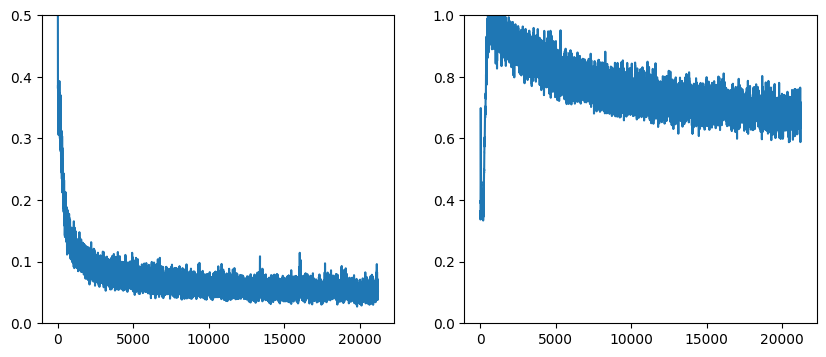

In [90]:
print('VAE training...')
for step in tqdm(range(15_000), desc='VAE training', leave=False):
    
    vae_loss_dict = reward_generator.train_step_VAE(
        batch_size=256,
        min_num_anchors=MIN_NUM_ANCHORS,
        max_num_anchors=MAX_NUM_ANCHORS,
    )
    vae_loss.append(vae_loss_dict['loss'])
    vae_kl_loss.append(vae_loss_dict['kl_loss'])   
    
    # break
    
    if step % 100 == 0:
        clear_output(True)
        fig, axs = plt.subplots(1, 2, figsize=(10, 4))
        axs[0].plot(vae_loss)
        axs[0].set_ylim([0, 0.5])
        # axs[0].set_xscale('log')
        axs[1].plot(vae_kl_loss)
        axs[1].set_ylim([0, 1])
        plt.show()
    # break

In [83]:
def sample_reward_function_fre_RG(batch_size, num_random_samples):

    trajectories_idx = torch.randint(0, num_trajectories, (batch_size*num_random_samples,))
    # states_idx = torch.randint(0, len_trajectory, (batch_size*num_random_samples,))
    states_idx = torch.randint(0, 1000, (batch_size*num_random_samples,))

    random_states = dataset_trajectories[trajectories_idx, states_idx] # get the random states
    random_states = random_states.reshape(batch_size, num_random_samples, STATE_DIM).to(device)

    reward_params = torch.zeros((batch_size, 128))
    random_states_rewards = torch.zeros((batch_size, num_random_samples))


    # num_anchors = 16
    if random.random() < 0.5:
        mask = reward_generator.generate_boolean_mask(batch_size, STATE_DIM, p=0.9)
    else:
        mask = reward_generator.generate_boolean_mask(batch_size, STATE_DIM, p=0.9)
    # mask = torch.zeros_like(mask)
    # mask[..., [0, 1]] = 1
    

    with torch.no_grad():
        reward_params, _ = reward_generator.get_z_from_random_anchors(batch_size, min_num_anchors=MIN_NUM_ANCHORS, max_num_anchors=MAX_NUM_ANCHORS, mask=mask)
        
        x = random_states * mask.unsqueeze(1).repeat(1, num_random_samples, 1).to(device)
        
        random_states_rewards = reward_generator.get_reward(
            x.reshape(-1, obs_dim), 
            reward_params.unsqueeze(1).repeat(1, num_random_samples, 1).reshape(-1, 128)
        ).reshape(batch_size, num_random_samples)
    
    return reward_params, random_states, random_states_rewards, mask

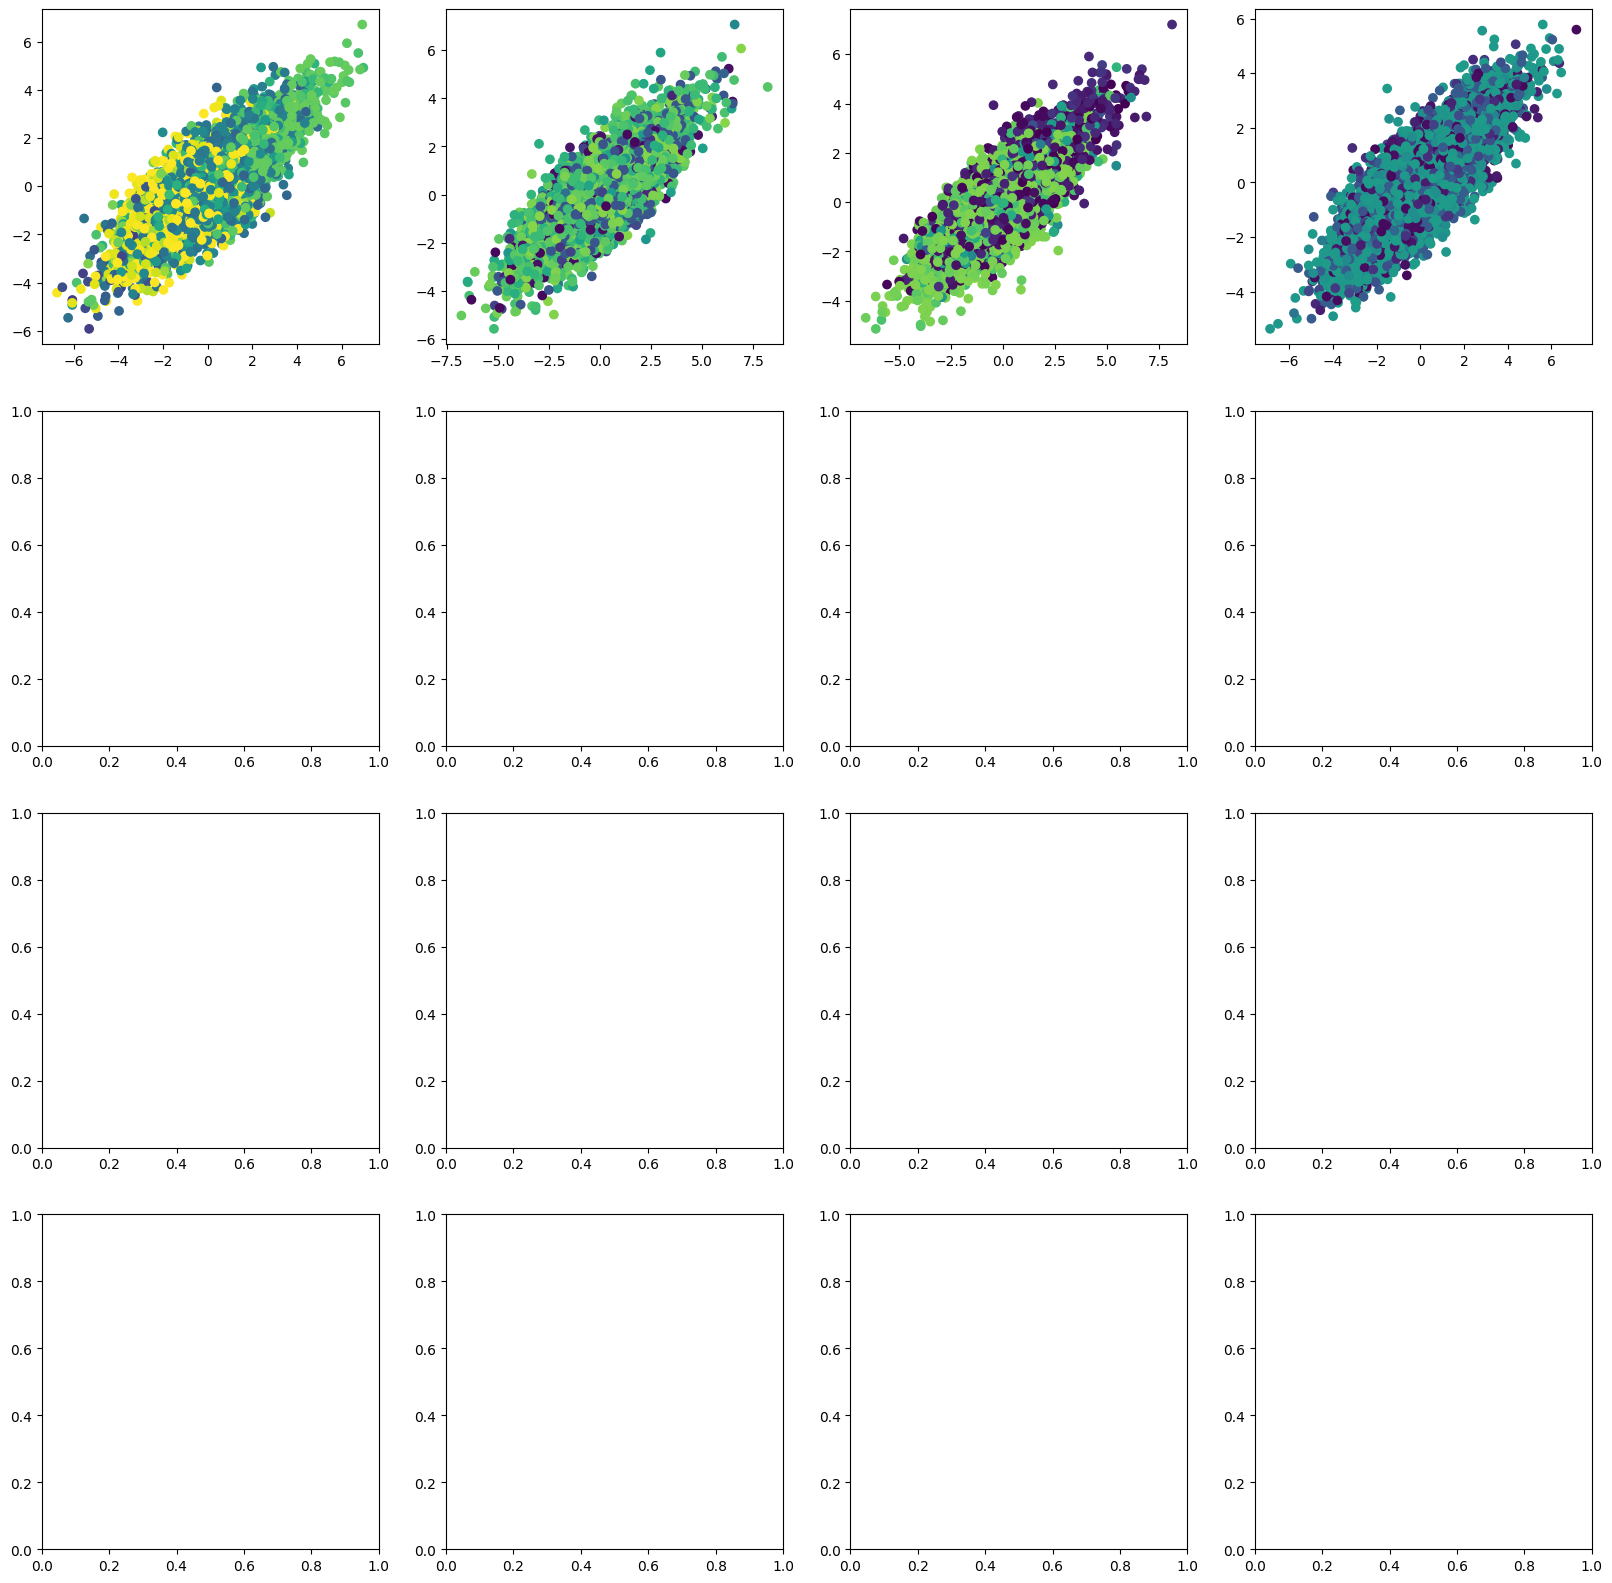

In [85]:
fig, axs = plt.subplots(4, 4, figsize=(20, 20))
axs = axs.flatten()

reward_params, random_states, random_states_rewards, mask = sample_reward_function_fre_RG(batch_size=4, num_random_samples=10000)

for b in range(4):
    axs[b].scatter(random_states[b, :, 8].cpu(), random_states[b, :, 17].cpu(), c=random_states_rewards[b].cpu(), vmin=-1, vmax=1)

In [52]:
random_states.shape

torch.Size([1000, 100, 18])

In [86]:
def sample_reward_function_fre_RG_2():
    
    batch_size = 1
    num_random_samples = 1000*100

    # trajectories_idx = torch.randint(0, num_trajectories, (batch_size*num_random_samples,))
    # states_idx = torch.randint(0, len_trajectory, (batch_size*num_random_samples,))
    # states_idx = torch.randint(0, 1000, (batch_size*num_random_samples,))

    # random_states = dataset_trajectories[trajectories_idx, states_idx] # get the random states
    random_states = dataset_trajectories[::10, ::10, :]

    random_states = random_states.reshape(1, num_random_samples, STATE_DIM).to(device)

    reward_params = torch.zeros((batch_size, 128))
    random_states_rewards = torch.zeros((batch_size, num_random_samples))


    # num_anchors = 16
    if random.random() < 0.5:
        mask = reward_generator.generate_boolean_mask(batch_size, STATE_DIM, p=0.9)
    else:
        mask = reward_generator.generate_boolean_mask(batch_size, STATE_DIM, p=0.5)
    # mask = torch.zeros_like(mask)
    # mask[..., [0, 1]] = 1
    

    with torch.no_grad():
        reward_params, _ = reward_generator.get_z_from_random_anchors(batch_size, min_num_anchors=MIN_NUM_ANCHORS, max_num_anchors=MAX_NUM_ANCHORS, mask=mask)
        
        x = random_states * mask.unsqueeze(1).repeat(1, num_random_samples, 1).to(device)
        
        random_states_rewards = reward_generator.get_reward(
            x.reshape(-1, obs_dim), 
            reward_params.unsqueeze(1).repeat(1, num_random_samples, 1).reshape(-1, 128)
        ).reshape(batch_size, num_random_samples)
    
    return reward_params, random_states, random_states_rewards, mask

In [91]:
stds = []

for _ in tqdm(range(5000)):
    reward_params, random_states, random_states_rewards, mask = sample_reward_function_fre_RG_2()
    
    stds.append(random_states_rewards.reshape(1000, 100).mean(dim=1).std().item())

100%|██████████| 5000/5000 [03:28<00:00, 24.02it/s]


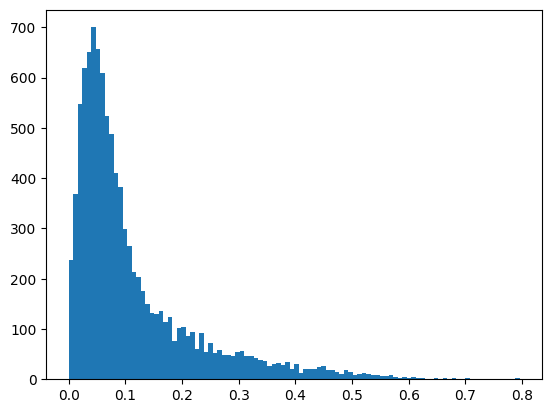

In [80]:
_ = plt.hist(stds, bins=100)

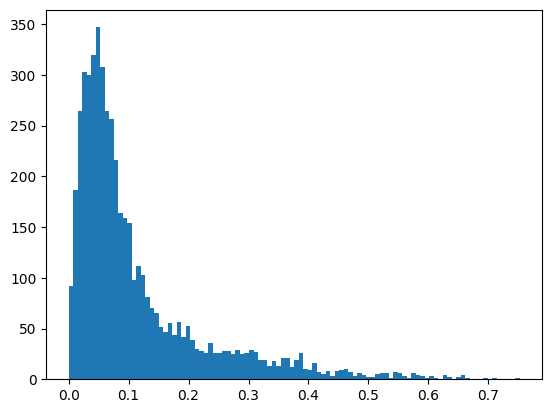

In [89]:
_ = plt.hist(stds, bins=100)

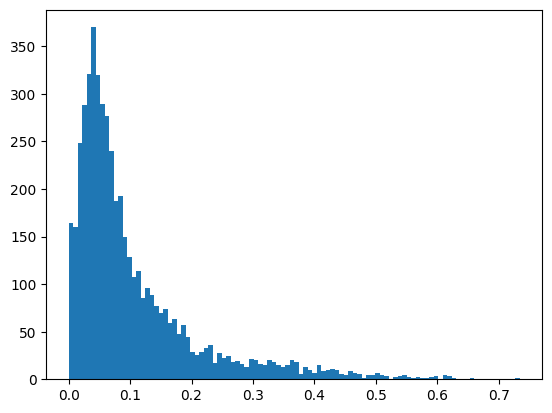

In [93]:
_ = plt.hist(stds, bins=100)